In [73]:
import pandas as pd
df = pd.read_csv(r"..\dataset\dataset_module_one_DM2.csv")

In [74]:
df["sii"].value_counts()

sii
0.0    5788
1.0    1573
2.0     940
3.0      83
Name: count, dtype: int64

## Preparazione dei Dati

In [75]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

# Extract features and target
X = df.drop('sii', axis=1).values
y = df['sii'].values

# Train/Val/Test split (60-20-20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

target_counts = {
    0: 3493, # Untouched
    1: 2000, # Moderate boost
    2: 2000, # Moderate boost
    3: 1500  # Targeted inflation as requested
}
smote = SMOTE(sampling_strategy=target_counts, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_resampled)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# One-Hot Encoding for Categorical Cross-Entropy
y_train_ohe = to_categorical(y_train_resampled, num_classes=4)
y_val_ohe = to_categorical(y_val, num_classes=4)
y_test_ohe = to_categorical(y_test, num_classes=4)

## Costruzione del Modello e Prevenzione dell'Overfitting

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import F1Score, AUC
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    
    # Input & Hidden Layers tuning
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
            activation='relu',
            kernel_regularizer=l2(0.001), # L2 Regularization
            input_shape=(X_train.shape[1],) if i == 0 else None
        ))
        # Dropout layer
        model.add(Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    
    # Output Layer (4 nodes, Softmax)
    model.add(Dense(4, activation='softmax'))
    
    # Optimizer tuning (Adam vs RMSprop)
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop'])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', 
                  metrics=[
                      AUC(name='auc'), F1Score(average='macro', name='macro_f1')
                    ])
    
    return model

## Hyper-parameter Tuning

In [77]:
from tensorflow.keras.callbacks import EarlyStopping

# Subclass RandomSearch to tune batch_size
class BatchTuner(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        kwargs['batch_size'] = trial.hyperparameters.Choice('batch_size', [32, 64, 128])
        return super().run_trial(trial, *args, **kwargs)

tuner = BatchTuner(
    build_model,
    objective=kt.Objective('val_macro_f1', direction='max'),
    max_trials=10,
    directory='tuning_logs',
    project_name='mlp_sii_2.0'
)

# Early Stopping callback
early_stopping = EarlyStopping(monitor='val_macro_f1', patience=10, restore_best_weights=True)

# Execute search
tuner.search(
    X_train, y_train_ohe,
    epochs=100,
    validation_data=(X_val, y_val_ohe),
    callbacks=[early_stopping],
    verbose=1,
)

best_model = tuner.get_best_models(num_models=1)[0]
best_model

Trial 10 Complete [00h 00m 23s]
val_macro_f1: 0.3517201840877533

Best val_macro_f1 So Far: 0.3600183129310608
Total elapsed time: 00h 05m 15s


c:\Users\nicco\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<Sequential name=sequential, built=True>

## Test set e ROC

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report:

              precision    recall  f1-score   support

         0.0      0.763     0.816     0.789      1150
         1.0      0.371     0.189     0.251       328
         2.0      0.261     0.395     0.315       177
         3.0      0.077     0.045     0.057        22

    accuracy                          0.639      1677
   macro avg      0.368     0.361     0.353      1677
weighted avg      0.625     0.639     0.624      1677



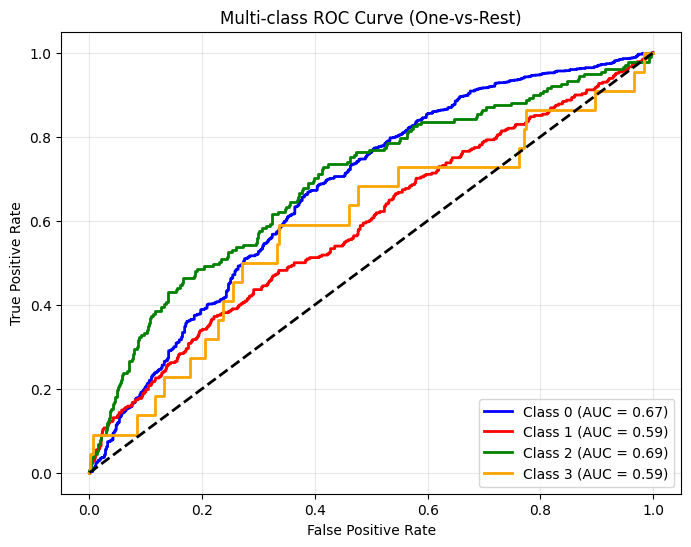

In [78]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, auc

# Predictions
y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Multi-class ROC Curve (One-vs-Rest)
fpr, tpr, roc_auc = {}, {}, {}
for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_test_ohe[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']

for i, color in zip(range(4), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Reloading Tuner from tuning_logs\mlp_sii_fixed_v1\tuner0.json


c:\Users\nicco\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\nicco\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report:

              precision    recall  f1-score   support

         0.0      0.767     0.793     0.780      1150
         1.0      0.362     0.140     0.202       328
         2.0      0.232     0.384     0.289       177
         3.0      0.044     0.136     0.067        22

    accuracy                          0.614      1677
   macro avg      0.351     0.363     0.335      1677
weighted avg      0.622     0.614     0.606      1677



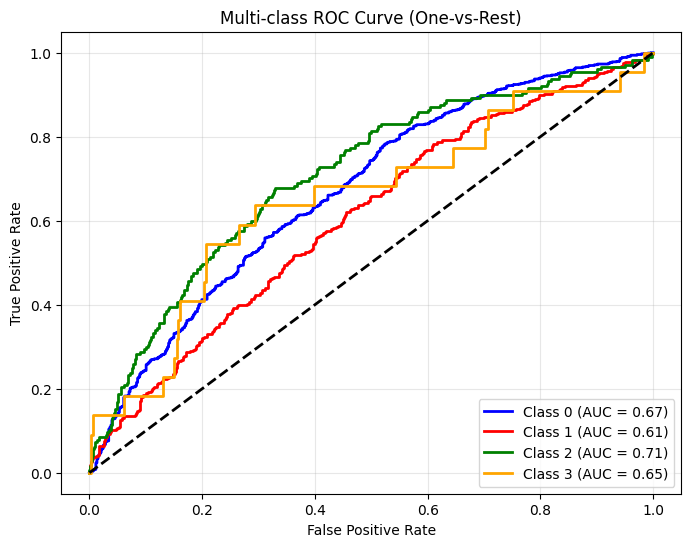

In [79]:
# ==========================================
# 0. LIBRERIE E IMPORT
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc

from imblearn.over_sampling import SMOTE

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import AUC, F1Score
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

# ==========================================
# 1. CARICAMENTO E PREPARAZIONE DATI
# ==========================================
# Assicurati che il percorso del file sia corretto per il tuo ambiente
df = pd.read_csv(r"..\dataset\dataset_module_one_DM2.csv")

# Estrazione feature e target
X = df.drop('sii', axis=1).values
y = df['sii'].values

# Train/Val/Test split (60-20-20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Calcolo dinamico per lo SMOTE basato solo sul training set attuale
train_counts = dict(zip(*np.unique(y_train, return_counts=True)))
majority_class_count = train_counts[0] 

target_counts = {
    0: majority_class_count,           # Intatto: rimane come nel train set
    1: int(majority_class_count * 0.6), # Boost moderato
    2: int(majority_class_count * 0.6), # Boost moderato
    3: int(majority_class_count * 0.4)  # Boost mirato (circa 1380 righe)
}

# Applicazione SMOTE
smote = SMOTE(sampling_strategy=target_counts, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Feature scaling (fit SOLO sui dati di training resamplati)
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# One-Hot Encoding per la Rete Neurale
y_train_ohe = to_categorical(y_train_resampled, num_classes=4)
y_val_ohe = to_categorical(y_val, num_classes=4)
y_test_ohe = to_categorical(y_test, num_classes=4)


# ==========================================
# 2. COSTRUZIONE DEL MODELLO
# ==========================================
def build_model(hp):
    model = Sequential()
    
    # Input & Hidden Layers tuning
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
            activation='relu',
            kernel_regularizer=l2(0.001), # Regolarizzazione L2
            input_shape=(X_train_resampled.shape[1],) if i == 0 else None
        ))
        # Dropout layer per prevenire overfitting
        model.add(Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    
    # Output Layer (4 nodi, Softmax per multi-classe)
    model.add(Dense(4, activation='softmax'))
    
    # Ottimizzatore e Metriche sbilanciate (Macro F1 e AUC)
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop'])
    model.compile(
        optimizer=optimizer, 
        loss='categorical_crossentropy', 
        metrics=[AUC(name='auc'), F1Score(average='macro', name='macro_f1')]
    )
    
    return model


# ==========================================
# 3. HYPER-PARAMETER TUNING
# ==========================================
# Sottoclasse per testare la dimensione del batch
class BatchTuner(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        kwargs['batch_size'] = trial.hyperparameters.Choice('batch_size', [32, 64, 128])
        return super().run_trial(trial, *args, **kwargs)

tuner = BatchTuner(
    build_model,
    objective=kt.Objective('val_macro_f1', direction='max'), # Ottimizza per Macro F1
    max_trials=10,
    directory='tuning_logs',
    project_name='mlp_sii_fixed_v1' # Nuovo nome per forzare una ricerca pulita
)

# Early Stopping monitorando la F1-Score
early_stopping = EarlyStopping(
    monitor='val_macro_f1', 
    mode='max', 
    patience=10, 
    restore_best_weights=True
)

# Esecuzione della ricerca
tuner.search(
    X_train_resampled, y_train_ohe,
    epochs=100,
    validation_data=(X_val_scaled, y_val_ohe),
    callbacks=[early_stopping],
    verbose=1
)

# Estrazione del miglior modello trovato
best_model = tuner.get_best_models(num_models=1)[0]


# ==========================================
# 4. VALUTAZIONE SUL TEST SET E PLOT
# ==========================================
# Previsioni (usando i dati di test SCALATI)
y_pred_probs = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Curve ROC Multi-classe (One-vs-Rest)
fpr, tpr, roc_auc = {}, {}, {}
for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_test_ohe[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting delle curve
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']

for i, color in zip(range(4), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Linea di riferimento diagonale
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()